<a href="https://colab.research.google.com/github/MonaKhadija/Data-Analytics-and-Artificial-Intelligence-Project-DAAI/blob/main/Project5_khadija_bassiouni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 5: Basic Natural Language Processing with Unsupervised Learning.**

Student name: Khadija Bassiouni

**Part 1 — Load and Explore the Data:**

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Loading the dataset (removing headers, footers, and quotes to reduce noise)
dataset = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

print("Number of documents:", len(dataset.data))
print("Number of categories:", len(dataset.target_names))
print("Category names:\n", dataset.target_names)

Number of documents: 11314
Number of categories: 20
Category names:
 ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [2]:
# Print a few example documents
print("\n--- Example Document 1 ---")
print(dataset.data[0][:400])
print("\n--- Example Document 2 ---")
print(dataset.data[1][:400])


--- Example Document 1 ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, h

--- Example Document 2 ---
A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the nex


**Part 2 — Convert Text into Numbers:**

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initializing TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Transforming the text data into numerical TF-IDF features
X = vectorizer.fit_transform(dataset.data)

print("Number of documents:", X.shape[0])
print("Number of features (words):", X.shape[1])
print("\nA few feature/word names:", vectorizer.get_feature_names_out()[:15])

Number of documents: 11314
Number of features (words): 5000

A few feature/word names: ['00' '000' '01' '02' '03' '04' '040' '05' '06' '07' '08' '09' '0d' '0i'
 '0m']


**Part 3 — Group the Documents:**

In [4]:
from sklearn.cluster import KMeans
import numpy as np

true_k = 5
kmeans = KMeans(n_clusters=true_k, init='k-means++', random_state=42)
kmeans.fit(X)

# Examinig cluster assignments and sizes
print("First 20 cluster assignments:", kmeans.labels_[:20])

unique, counts = np.unique(kmeans.labels_, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} documents")

First 20 cluster assignments: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Cluster 0: 1 documents
Cluster 1: 1 documents
Cluster 2: 1 documents
Cluster 3: 11310 documents
Cluster 4: 1 documents


**Part 4 — Understand the Clusters:**

In [5]:
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    print(f"\nCluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print("  Common words:", ", ".join(top_words))


Cluster 0:
  Common words: mileage, highway, covers, charles, affect, travel, comment, building, thinking, ve

Cluster 1:
  Common words: educational, repair, sales, tax, order, apple, mail, cpu, computers, probably

Cluster 2:
  Common words: objective, society, ideal, blame, innocent, murder, totally, yes, prevent, possible

Cluster 3:
  Common words: like, just, know, don, people, think, does, use, thanks, good

Cluster 4:
  Common words: window, dialog, trivial, massive, justified, settings, menu, square, complicated, corner


**Part 5 — Visualize the Clusters:**

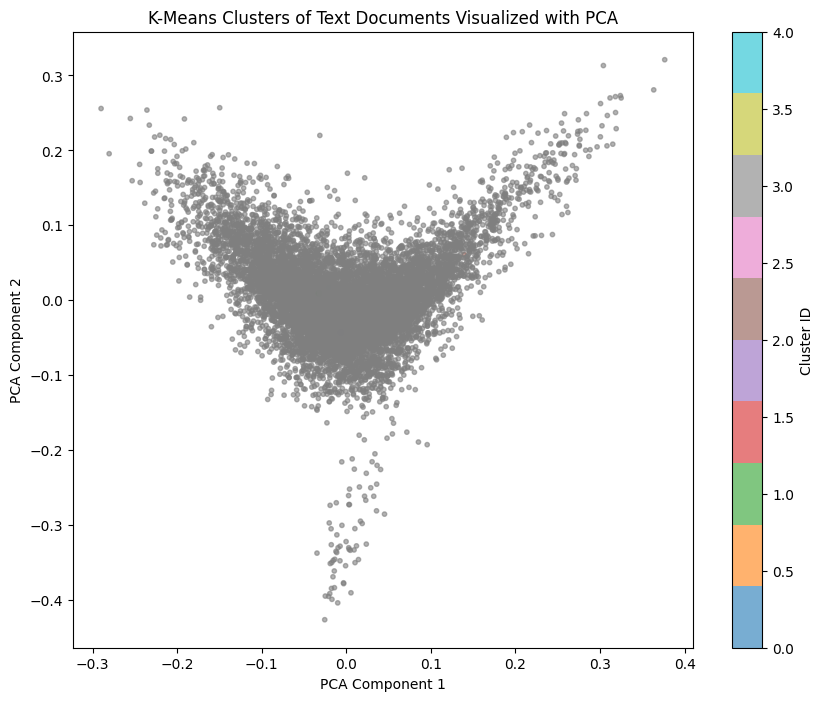

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reducing high-dimensional TF-IDF features to 2 dimensions
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(X.toarray())

# Creating a scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=kmeans.labels_, cmap='tab10', s=10, alpha=0.6)
plt.title("K-Means Clusters of Text Documents Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.show()